# Spam Detection Using Traditional Machine Learning, Deep Learning and Transformer Models

## Project Overview

Spam messages and emails are one of the most common forms of unwanted digital communication. These messages often contain advertisements, phishing attempts, scams, fraudulent offers, or misleading information intended to deceive users.

The objective of this project is to build an automated spam detection system capable of classifying incoming messages as either Spam or Ham (Legitimate).

Rather than relying on a single modelling approach, our team aims to compare multiple Natural Language Processing (NLP) techniques across three major categories:

- Traditional Machine Learning
- Deep Learning
- Transformer-based Models

The final goal is to identify which approach provides the best balance between performance, generalization capability, and computational efficiency.

The project will conclude with a deployed Streamlit application that demonstrates real-time spam classification.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import string
import nltk
import json
import matplotlib.pyplot as plt
import os

os.makedirs(
    "../results/figures",
    exist_ok=True
)

from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

nltk.download("wordnet")
nltk.download("punkt")
nltk.download("stopwords")
print("Imports Done")

Imports Done


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rstar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rstar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rstar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Dataset Loading and Initial Inspection

In this section, the SMS Spam Collection dataset is loaded and inspected.

The original dataset contains labelled SMS messages belonging to two categories:

- Ham (Legitimate Message)
- Spam (Unwanted Message)

In [2]:
df = pd.read_csv(
    "../data/raw/spam.csv",
    encoding="latin-1"
)

df.drop(
    columns=[
        'Unnamed: 2',
        'Unnamed: 3',
        'Unnamed: 4'
    ],
    inplace=True
)

df.rename(
    columns={
        'v1':'label',
        'v2':'text'
    },
    inplace=True
)

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Data Quality Assessment

Real-world datasets frequently contain duplicate records that may bias model training and evaluation.

To ensure fair learning and reliable performance measurement, duplicate messages are identified and removed from the dataset.

In [3]:
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicates")
print(df.duplicated().sum())

(5572, 2)

Missing Values
label    0
text     0
dtype: int64

Duplicates
403


In [4]:
df = df.drop_duplicates()

print(df.shape)

(5169, 2)


## Exploratory Data Analysis (EDA)

Before applying any NLP techniques, we perform exploratory analysis to better understand the characteristics of the dataset.

The following analyses are performed:

- Distribution of Spam and Ham messages
- Message length statistics
- Character count analysis
- Word count analysis

These insights help us understand class balance and message characteristics that may influence model behaviour.

In [5]:
print(df["label"].value_counts())

print()

print(
    df["label"].value_counts(normalize=True)*100
)

label
ham     4516
spam     653
Name: count, dtype: int64

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


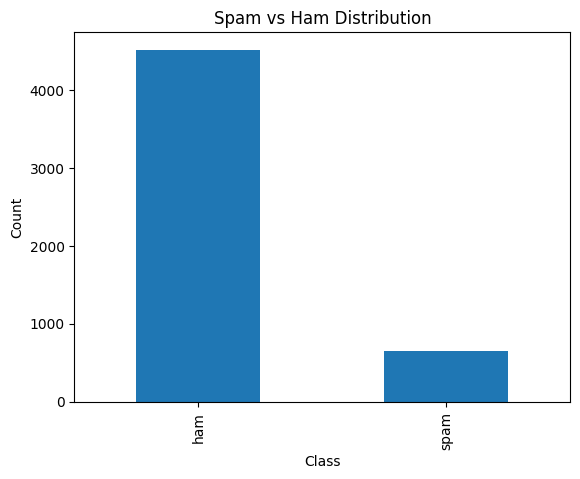

In [6]:
df["label"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Spam vs Ham Distribution"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig(
    "../results/figures/class_distribution.png",
    bbox_inches="tight"
)
plt.show()

In [7]:
df["char_count"] = df["text"].apply(len)

df["word_count"] = df["text"].apply(
    lambda x: len(x.split())
)

In [8]:
print(
    df.groupby("label")[
        ["char_count","word_count"]
    ].mean()
)

       char_count  word_count
label                        
ham     70.459256   14.134632
spam   137.891271   23.681470


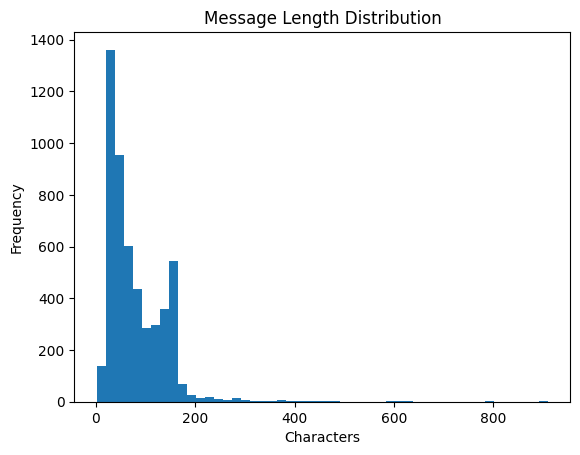

In [9]:
plt.hist(
    df["char_count"],
    bins=50
)

plt.title(
    "Message Length Distribution"
)

plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.savefig(
    "../results/figures/message_length_distribution.png",
    bbox_inches="tight"
)
plt.show()

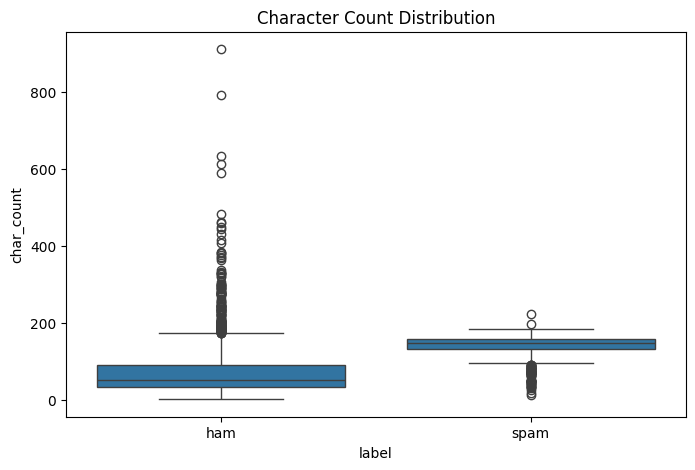

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="char_count"
)

plt.title(
    "Character Count Distribution"
)

plt.savefig(
    "../results/figures/char_count_boxplot.png",
    bbox_inches="tight"
)

plt.show()

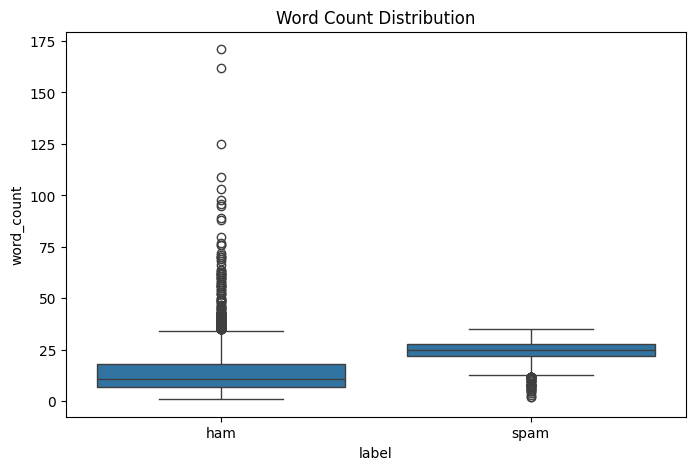

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title(
    "Word Count Distribution"
)

plt.savefig(
    "../results/figures/word_count_boxplot.png",
    bbox_inches="tight"
)

plt.show()

## Text Preprocessing

Raw text cannot be directly used by machine learning algorithms.

Therefore, a preprocessing pipeline is applied to standardize the text and reduce noise.

The preprocessing steps include:

1. Lowercasing
2. URL Removal
3. Number Removal
4. Punctuation Removal
5. Stopword Removal
6. Lemmatization

The output of this stage is a cleaned text representation that will be used during feature extraction and model training.

In [12]:
stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"\d+",
        " ",
        text
    )

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    tokens = nltk.word_tokenize(text)

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    tokens = [
    lemmatizer.lemmatize(word)
    for word in tokens
    ]

    return " ".join(tokens)

In [13]:
df["clean_text"] = df["text"].apply(
    clean_text
)
df["clean_text"] = (
    df["clean_text"]
    .fillna("")
    .astype(str)
)
df = df[
    df["clean_text"].str.strip() != ""
]
df[
    ["text","clean_text"]
].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [14]:
print(
    "Remaining NaNs:",
    df["clean_text"].isna().sum()
)

print(
    "Empty strings:",
    (df["clean_text"].str.strip() == "").sum()
)

Remaining NaNs: 0
Empty strings: 0


In [15]:
summary = pd.DataFrame({

    "Metric":[
        "Total Messages",
        "Spam Messages",
        "Ham Messages"
    ],

    "Value":[
        len(df),
        (df["label"]=="spam").sum(),
        (df["label"]=="ham").sum()
    ]
})

print(summary)

summary.to_csv(
    "../results/dataset_summary.csv",
    index=False
)

           Metric  Value
0  Total Messages   5163
1   Spam Messages    653
2    Ham Messages   4510


## Label Encoding

Machine learning algorithms require numerical target values.

The original class labels are therefore converted into numerical form:

- Ham → 0
- Spam → 1

This encoded representation will be used consistently throughout the remainder of the project.

In [16]:
encoder = LabelEncoder()

df["target"] = encoder.fit_transform(
    df["label"]
)

print(df[["label","target"]].head())

  label  target
0   ham       0
1   ham       0
2  spam       1
3   ham       0
4   ham       0


## Dataset Splitting Strategy

To ensure fair and reproducible evaluation, the dataset is divided into three subsets:

- Training Set (70%)
- Validation Set (15%)
- Test Set (15%)

The split is performed using stratified sampling to preserve the original class distribution across all subsets.

These saved splits will be reused by every subsequent notebook in the project, ensuring that all machine learning, deep learning, and transformer models are evaluated on exactly the same data.

In [17]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

In [18]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [19]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (3614, 6)
Validation: (774, 6)
Test: (775, 6)


In [20]:
split_stats = pd.DataFrame({

    "Dataset":[
        "Train",
        "Validation",
        "Test"
    ],

    "Rows":[
        len(train_df),
        len(val_df),
        len(test_df)
    ]
})
split_stats.to_csv(
    "../results/split_statistics.csv",
    index=False
)

In [21]:
print(
    train_df["label"]
    .value_counts(normalize=True)
)

print(
    val_df["label"]
    .value_counts(normalize=True)
)

print(
    test_df["label"]
    .value_counts(normalize=True)
)

label
ham     0.873547
spam    0.126453
Name: proportion, dtype: float64
label
ham     0.873385
spam    0.126615
Name: proportion, dtype: float64
label
ham     0.873548
spam    0.126452
Name: proportion, dtype: float64


## Data Persistence

The processed dataset and generated splits are saved for future use.

The saved files will serve as the common input source for:

- Traditional Machine Learning Models
- Deep Learning Models
- Transformer-based Models

This guarantees consistency across all experiments and prevents accidental changes to the training and testing data.

In [22]:
import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)

In [23]:
print(train_df.columns)

print(val_df.columns)

print(test_df.columns)

Index(['label', 'text', 'char_count', 'word_count', 'clean_text', 'target'], dtype='object')
Index(['label', 'text', 'char_count', 'word_count', 'clean_text', 'target'], dtype='object')
Index(['label', 'text', 'char_count', 'word_count', 'clean_text', 'target'], dtype='object')


In [24]:
train_df.to_csv(
    "../data/processed/train.csv",
    index=False
)

val_df.to_csv(
    "../data/processed/val.csv",
    index=False
)

test_df.to_csv(
    "../data/processed/test.csv",
    index=False
)

In [25]:
metadata = {

    "dataset_shape": list(df.shape),

    "features": list(df.columns),

    "random_state": 42,

    "split_ratio": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15
    },

    "preprocessing": [
        "lowercase",
        "url_removal",
        "number_removal",
        "punctuation_removal",
        "stopword_removal",
        "lemmatization"
    ]
}

with open(
    "../data/processed/preprocessing_metadata.json",
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )
print("Metadata Saved")

print(
    "../data/processed/train.csv"
)
print(
    "../data/processed/val.csv"
)
print(
    "../data/processed/test.csv"
)

Metadata Saved
../data/processed/train.csv
../data/processed/val.csv
../data/processed/test.csv


# Conclusion

In this notebook, we completed the data preparation phase of the spam detection project.

The dataset was successfully loaded, cleaned, analysed, and transformed into a format suitable for machine learning workflows. Duplicate records were removed, exploratory analysis was performed, and a comprehensive preprocessing pipeline was applied to standardize the text data.

The target labels were encoded and the dataset was split into training, validation, and testing subsets using a stratified strategy. These splits were then saved for reuse throughout the project.

The outputs generated in this notebook will be used as the foundation for all subsequent experiments.

Next Steps:

1. Traditional Machine Learning Models
   - Naive Bayes
   - Logistic Regression
   - Support Vector Machine (SVM)

2. Deep Learning Models
   - LSTM
   - Bidirectional LSTM

3. Transformer Models
   - DistilBERT
   - BERT

Finally, all approaches will be compared using common evaluation metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC. The best-performing model will then be integrated into a Streamlit-based web application for demonstration purposes.